In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

In [7]:
file_path = "/content/drive/MyDrive/CPC Hackathon/Dataset/PS_20174392719_1491204439457_log.csv"

In [8]:
df = pd.read_csv(file_path)

In [9]:
# ==============================
# 2. Basic Information
# ==============================

print("\n===== DATASET SHAPE =====")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


print("\n===== COLUMN NAMES =====")
print(df.columns.tolist())


# ==============================
# 3. First 5 Rows
# ==============================

print("\n===== FIRST 5 ROWS =====")
print(df.head())


# ==============================
# 4. Dataset Information
# ==============================

print("\n===== DATASET INFO =====")
df.info()


# ==============================
# 5. Statistical Summary
# ==============================

print("\n===== STATISTICAL SUMMARY =====")
print(df.describe())


# ==============================
# 6. Missing Values
# ==============================

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())


# ==============================
# 7. Duplicate Rows
# ==============================

print("\n===== DUPLICATE ROWS =====")
print("Duplicate rows:", df.duplicated().sum())


# ==============================
# 8. Unique Values
# ==============================

print("\n===== UNIQUE VALUES =====")

for column in df.columns:
    print(f"{column}: {df[column].nunique()}")


# ==============================
# 9. Transaction Types
# ==============================

print("\n===== TRANSACTION TYPES =====")
print(df["type"].value_counts())


# ==============================
# 10. Fraud Distribution
# ==============================

print("\n===== FRAUD DISTRIBUTION =====")
print(df["isFraud"].value_counts())


print("\n===== FRAUD PERCENTAGE =====")
print(df["isFraud"].value_counts(normalize=True) * 100)


# ==============================
# 11. Flagged Fraud Distribution
# ==============================

print("\n===== FLAGGED FRAUD =====")
print(df["isFlaggedFraud"].value_counts())


# ==============================
# 12. Fraud by Transaction Type
# ==============================

print("\n===== FRAUD BY TRANSACTION TYPE =====")

fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

print(fraud_by_type)


# ==============================
# 13. Amount Statistics
# ==============================

print("\n===== TRANSACTION AMOUNT =====")
print(df["amount"].describe())


# ==============================
# 14. Fraud Transaction Amount
# ==============================

print("\n===== FRAUD TRANSACTION AMOUNT =====")

fraud_transactions = df[df["isFraud"] == 1]

print(fraud_transactions["amount"].describe())


# ==============================
# 15. Legitimate Transaction Amount
# ==============================

print("\n===== LEGITIMATE TRANSACTION AMOUNT =====")

normal_transactions = df[df["isFraud"] == 0]

print(normal_transactions["amount"].describe())


===== DATASET SHAPE =====
Rows: 6362620
Columns: 11

===== COLUMN NAMES =====
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

===== FIRST 5 ROWS =====
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0

In [10]:
# ============================================
# PART 1: DATA CLEANING
# ============================================

# 1. Make a copy
data = df.copy()

print("Initial shape:", data.shape)

# --------------------------------------------
# 2. Check missing values
# --------------------------------------------

print("\nMissing values:")
print(data.isnull().sum())


# --------------------------------------------
# 3. Check duplicate rows
# --------------------------------------------

print("\nDuplicate rows:", data.duplicated().sum())


# --------------------------------------------
# 4. Check negative values
# --------------------------------------------

numeric_columns = [
    'step',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]

print("\nNegative values:")

for col in numeric_columns:
    print(col, ":", (data[col] < 0).sum())


# --------------------------------------------
# 5. Check transaction amount
# --------------------------------------------

print("\nAmount <= 0:")
print((data['amount'] <= 0).sum())


# --------------------------------------------
# 6. Remove duplicate rows
# --------------------------------------------

data = data.drop_duplicates()

print("\nShape after removing duplicates:", data.shape)


# --------------------------------------------
# 7. Remove isFlaggedFraud
# --------------------------------------------

data = data.drop(columns=['isFlaggedFraud'])

print("\nColumns after removing isFlaggedFraud:")
print(data.columns.tolist())


# --------------------------------------------
# 8. Final check
# --------------------------------------------

print("\nFinal shape:", data.shape)

print("\nData types:")
print(data.dtypes)

Initial shape: (6362620, 11)

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows: 0

Negative values:
step : 0
amount : 0
oldbalanceOrg : 0
newbalanceOrig : 0
oldbalanceDest : 0
newbalanceDest : 0

Amount <= 0:
16

Shape after removing duplicates: (6362620, 11)

Columns after removing isFlaggedFraud:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']

Final shape: (6362620, 10)

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object


In [11]:
# ============================================
# PART 2: BASIC FEATURE ENGINEERING
# ============================================

import numpy as np


# --------------------------------------------
# 1. Origin account balance change
# --------------------------------------------

data['orig_balance_change'] = (
    data['oldbalanceOrg'] - data['newbalanceOrig']
)


# --------------------------------------------
# 2. Destination account balance change
# --------------------------------------------

data['dest_balance_change'] = (
    data['newbalanceDest'] - data['oldbalanceDest']
)


# --------------------------------------------
# 3. Amount / Origin balance ratio
# --------------------------------------------

data['amount_to_orig_balance'] = (
    data['amount'] /
    (data['oldbalanceOrg'] + 1)
)


# --------------------------------------------
# 4. Amount / Destination balance ratio
# --------------------------------------------

data['amount_to_dest_balance'] = (
    data['amount'] /
    (data['oldbalanceDest'] + 1)
)


# --------------------------------------------
# 5. Origin balance error
# --------------------------------------------

data['orig_balance_error'] = (
    data['oldbalanceOrg']
    - data['amount']
    - data['newbalanceOrig']
)


# --------------------------------------------
# 6. Destination balance error
# --------------------------------------------

data['dest_balance_error'] = (
    data['oldbalanceDest']
    + data['amount']
    - data['newbalanceDest']
)


# --------------------------------------------
# 7. Log transformed transaction amount
# --------------------------------------------

data['log_amount'] = np.log1p(data['amount'])


# --------------------------------------------
# 8. Check newly created features
# --------------------------------------------

new_features = [
    'orig_balance_change',
    'dest_balance_change',
    'amount_to_orig_balance',
    'amount_to_dest_balance',
    'orig_balance_error',
    'dest_balance_error',
    'log_amount'
]

print("\nNew features:")
print(data[new_features].head())


# --------------------------------------------
# 9. Check statistics
# --------------------------------------------

print("\nFeature statistics:")
print(data[new_features].describe())


New features:
   orig_balance_change  dest_balance_change  amount_to_orig_balance  \
0              9839.64                  0.0                0.057834   
1              1864.28                  0.0                0.087731   
2               181.00                  0.0                0.994505   
3               181.00             -21182.0                0.994505   
4             11668.14                  0.0                0.280788   

   amount_to_dest_balance  orig_balance_error  dest_balance_error  log_amount  
0             9839.640000                 0.0             9839.64    9.194276  
1             1864.280000                 0.0             1864.28    7.531166  
2              181.000000                 0.0              181.00    5.204007  
3                0.008545                 0.0            21363.00    5.204007  
4            11668.140000                 0.0            11668.14    9.364703  

Feature statistics:
       orig_balance_change  dest_balance_change  amount_t

In [12]:
# ============================================
# PART 3: TIME-BASED FEATURE ENGINEERING
# ============================================

import numpy as np


# --------------------------------------------
# 1. Extract hour of day
# --------------------------------------------

data['hour'] = data['step'] % 24


# --------------------------------------------
# 2. Extract day number
# --------------------------------------------

data['day'] = data['step'] // 24


# --------------------------------------------
# 3. Night-time indicator
# --------------------------------------------

data['is_night'] = (
    (data['hour'] >= 0) &
    (data['hour'] < 6)
).astype(int)


# --------------------------------------------
# 4. Cyclic hour encoding
# --------------------------------------------

data['hour_sin'] = np.sin(
    2 * np.pi * data['hour'] / 24
)

data['hour_cos'] = np.cos(
    2 * np.pi * data['hour'] / 24
)


# --------------------------------------------
# 5. Check new features
# --------------------------------------------

time_features = [
    'step',
    'hour',
    'day',
    'is_night',
    'hour_sin',
    'hour_cos'
]

print("\nTime features:")
print(data[time_features].head(10))


# --------------------------------------------
# 6. Check hour distribution
# --------------------------------------------

print("\nTransaction count by hour:")
print(data['hour'].value_counts().sort_index())


# --------------------------------------------
# 7. Check night transactions
# --------------------------------------------

print("\nNight transaction distribution:")
print(data['is_night'].value_counts())


Time features:
   step  hour  day  is_night  hour_sin  hour_cos
0     1     1    0         1  0.258819  0.965926
1     1     1    0         1  0.258819  0.965926
2     1     1    0         1  0.258819  0.965926
3     1     1    0         1  0.258819  0.965926
4     1     1    0         1  0.258819  0.965926
5     1     1    0         1  0.258819  0.965926
6     1     1    0         1  0.258819  0.965926
7     1     1    0         1  0.258819  0.965926
8     1     1    0         1  0.258819  0.965926
9     1     1    0         1  0.258819  0.965926

Transaction count by hour:
hour
0      71587
1      27111
2       9018
3       2007
4       1241
5       1641
6       3420
7       8988
8      26915
9     283518
10    425729
11    445992
12    483418
13    468474
14    439653
15    416686
16    441612
17    439941
18    580509
19    647814
20    553728
21    247806
22    194555
23    141257
Name: count, dtype: int64

Night transaction distribution:
is_night
0    6250015
1     112605
Name: 

In [13]:
# ============================================
# PART 4: USER BEHAVIORAL FEATURES
# ============================================

# Make sure data is ordered chronologically
data = data.sort_values('step').reset_index(drop=True)


# --------------------------------------------
# 1. Transaction count BEFORE current transaction
# --------------------------------------------

data['user_tx_count_before'] = (
    data.groupby('nameOrig').cumcount()
)


# --------------------------------------------
# 2. Previous total transaction amount
# --------------------------------------------

data['user_amount_sum_before'] = (
    data.groupby('nameOrig')['amount']
    .cumsum()
    .sub(data['amount'])
)


# --------------------------------------------
# 3. Previous average transaction amount
# --------------------------------------------

data['user_avg_amount_before'] = (
    data['user_amount_sum_before'] /
    data['user_tx_count_before'].replace(0, np.nan)
)

data['user_avg_amount_before'] = (
    data['user_avg_amount_before']
    .fillna(0)
)


# --------------------------------------------
# 4. Current amount compared with
#    user's historical average
# --------------------------------------------

data['amount_vs_user_avg'] = (
    data['amount'] /
    (data['user_avg_amount_before'] + 1)
)


# --------------------------------------------
# 5. Previous maximum transaction amount
# --------------------------------------------

data['user_max_amount_before'] = (
    data.groupby('nameOrig')['amount']
    .cummax()
    .groupby(data['nameOrig'])
    .shift(1)
    .fillna(0)
)

# Remove current transaction from maximum
data['user_max_amount_before'] = np.where(
    data['user_tx_count_before'] > 0,
    data['user_max_amount_before'],
    0
)


# --------------------------------------------
# 6. Check behavioral features
# --------------------------------------------

behavior_features = [
    'nameOrig',
    'amount',
    'user_tx_count_before',
    'user_amount_sum_before',
    'user_avg_amount_before',
    'amount_vs_user_avg',
    'user_max_amount_before'
]

print("\nUser behavioral features:")
print(data[behavior_features].head(20))


# --------------------------------------------
# 7. Statistics
# --------------------------------------------

print("\nBehavior feature statistics:")

print(
    data[
        [
            'user_tx_count_before',
            'user_amount_sum_before',
            'user_avg_amount_before',
            'amount_vs_user_avg',
            'user_max_amount_before'
        ]
    ].describe()
)


User behavioral features:
       nameOrig     amount  user_tx_count_before  user_amount_sum_before  \
0   C1137667747   42012.45                     0                     0.0   
1   C1723848804    5831.05                     0                     0.0   
2    C570422884    9855.36                     0                     0.0   
3    C509806761   10726.49                     0                     0.0   
4   C1859928417    1833.22                     0                     0.0   
5   C1378280450   34115.82                     0                     0.0   
6    C339788561    2210.66                     0                     0.0   
7   C2017380745   22190.99                     0                     0.0   
8    C501036152  168451.53                     0                     0.0   
9    C261567641  123545.77                     0                     0.0   
10  C1295225869   28463.91                     0                     0.0   
11   C803768841    4219.94                     0             

In [14]:
# ============================================
# PART 5: TRANSACTION TYPE ENCODING
# ============================================

# --------------------------------------------
# 1. Check transaction types
# --------------------------------------------

print("Transaction types:")
print(data['type'].value_counts())


# --------------------------------------------
# 2. One-hot encode transaction type
# --------------------------------------------

data = pd.get_dummies(
    data,
    columns=['type'],
    prefix='type',
    dtype=int
)


# --------------------------------------------
# 3. Check new columns
# --------------------------------------------

print("\nColumns after encoding:")
print(data.columns.tolist())


# --------------------------------------------
# 4. Check encoded type columns
# --------------------------------------------

type_columns = [
    col for col in data.columns
    if col.startswith('type_')
]

print("\nEncoded transaction type columns:")
print(type_columns)


# --------------------------------------------
# 5. Check values
# --------------------------------------------

print("\nEncoded type sample:")
print(data[type_columns].head(10))

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Columns after encoding:
['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'orig_balance_change', 'dest_balance_change', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_error', 'dest_balance_error', 'log_amount', 'hour', 'day', 'is_night', 'hour_sin', 'hour_cos', 'user_tx_count_before', 'user_amount_sum_before', 'user_avg_amount_before', 'amount_vs_user_avg', 'user_max_amount_before', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Encoded transaction type columns:
['type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Encoded type sample:
   type_CASH_IN  type_CASH_OUT  type_DEBIT  type_PAYMENT  type_TRANSFER
0             1              0           0             0              0
1      

In [15]:
# ============================================
# PART 6: FINAL FEATURE SELECTION
# ============================================

# --------------------------------------------
# 1. Separate target
# --------------------------------------------

y = data['isFraud'].copy()


# --------------------------------------------
# 2. Columns that should NOT be used
# --------------------------------------------

drop_columns = [
    'isFraud',
    'nameOrig',
    'nameDest'
]


# --------------------------------------------
# 3. Create feature dataset
# --------------------------------------------

X = data.drop(columns=drop_columns)


# --------------------------------------------
# 4. Check feature columns
# --------------------------------------------

print("Feature columns:")
print(X.columns.tolist())


# --------------------------------------------
# 5. Check shapes
# --------------------------------------------

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# --------------------------------------------
# 6. Check target distribution
# --------------------------------------------

print("\nTarget distribution:")
print(y.value_counts())


# --------------------------------------------
# 7. Check data types
# --------------------------------------------

print("\nFeature data types:")
print(X.dtypes)

Feature columns:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_change', 'dest_balance_change', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_error', 'dest_balance_error', 'log_amount', 'hour', 'day', 'is_night', 'hour_sin', 'hour_cos', 'user_tx_count_before', 'user_amount_sum_before', 'user_avg_amount_before', 'amount_vs_user_avg', 'user_max_amount_before', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

X shape: (6362620, 28)
y shape: (6362620,)

Target distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Feature data types:
step                        int64
amount                    float64
oldbalanceOrg             float64
newbalanceOrig            float64
oldbalanceDest            float64
newbalanceDest            float64
orig_balance_change       float64
dest_balance_change       float64
amount_to_orig_balance    float64
amount_to_dest_balance    flo

In [16]:
# ============================================
# PART 7: CHRONOLOGICAL TRAIN / VAL / TEST
# ============================================

# --------------------------------------------
# 1. Get split points based on row order
# --------------------------------------------

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)


# --------------------------------------------
# 2. Split X and y
# --------------------------------------------

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()


# --------------------------------------------
# 3. Check shapes
# --------------------------------------------

print("TRAIN")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nVALIDATION")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nTEST")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# --------------------------------------------
# 4. Check fraud distribution
# --------------------------------------------

print("\nFraud distribution:")

print("\nTRAIN:")
print(y_train.value_counts())

print("\nVALIDATION:")
print(y_val.value_counts())

print("\nTEST:")
print(y_test.value_counts())


# --------------------------------------------
# 5. Fraud percentage
# --------------------------------------------

print("\nFraud percentage:")

print(
    "Train:",
    y_train.mean() * 100,
    "%"
)

print(
    "Validation:",
    y_val.mean() * 100,
    "%"
)

print(
    "Test:",
    y_test.mean() * 100,
    "%"
)


# --------------------------------------------
# 6. Check time range
# --------------------------------------------

print("\nTime ranges:")

print(
    "Train step:",
    X_train['step'].min(),
    "→",
    X_train['step'].max()
)

print(
    "Validation step:",
    X_val['step'].min(),
    "→",
    X_val['step'].max()
)

print(
    "Test step:",
    X_test['step'].min(),
    "→",
    X_test['step'].max()
)

TRAIN
X_train: (4453834, 28)
y_train: (4453834,)

VALIDATION
X_val: (954393, 28)
y_val: (954393,)

TEST
X_test: (954393, 28)
y_test: (954393,)

Fraud distribution:

TRAIN:
isFraud
0    4450191
1       3643
Name: count, dtype: int64

VALIDATION:
isFraud
0    953831
1       562
Name: count, dtype: int64

TEST:
isFraud
0    950385
1      4008
Name: count, dtype: int64

Fraud percentage:
Train: 0.0817946964345775 %
Validation: 0.05888559534699018 %
Test: 0.41995278674508296 %

Time ranges:
Train step: 1 → 323
Validation step: 323 → 378
Test step: 378 → 743


In [17]:
# ============================================
# PART 8: CLASS IMBALANCE ANALYSIS
# ============================================

# --------------------------------------------
# 1. Count classes in training data
# --------------------------------------------

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()


# --------------------------------------------
# 2. Calculate scale_pos_weight
# --------------------------------------------

scale_pos_weight = negative_count / positive_count


# --------------------------------------------
# 3. Print class information
# --------------------------------------------

print("Negative samples:", negative_count)
print("Positive samples:", positive_count)

print(
    "\nScale Pos Weight:",
    scale_pos_weight
)


# --------------------------------------------
# 4. Check imbalance ratio
# --------------------------------------------

imbalance_ratio = negative_count / positive_count

print(
    "\nClass imbalance ratio:",
    f"1 : {imbalance_ratio:.2f}"
)


# --------------------------------------------
# 5. Check fraud percentage
# --------------------------------------------

fraud_percentage = (
    positive_count / len(y_train)
) * 100

print(
    "\nTraining fraud percentage:",
    f"{fraud_percentage:.4f}%"
)

Negative samples: 4450191
Positive samples: 3643

Scale Pos Weight: 1221.5731539939611

Class imbalance ratio: 1 : 1221.57

Training fraud percentage: 0.0818%


In [18]:
pip install xgboost

In [19]:
!nvidia-smi

Sat Oct  3 18:29:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
# ============================================
# PART 9: FAST XGBOOST TRAINING - T4 GPU
# ============================================

from xgboost import XGBClassifier
import time


# --------------------------------------------
# 1. Start timer
# --------------------------------------------

start_time = time.time()


# --------------------------------------------
# 2. Create fast XGBoost model
# --------------------------------------------

xgb_model = XGBClassifier(

    # Number of trees
    n_estimators=150,

    # Tree complexity
    max_depth=5,

    # Learning rate
    learning_rate=0.15,

    # Use part of data/features per tree
    subsample=0.8,
    colsample_bytree=0.8,

    # Handle severe class imbalance
    scale_pos_weight=scale_pos_weight,

    # Binary classification
    objective='binary:logistic',

    # Important for fraud detection
    eval_metric='aucpr',

    # GPU
    tree_method='hist',
    device='cuda',

    # Faster training
    n_jobs=-1,

    random_state=42
)


# --------------------------------------------
# 3. Train
# --------------------------------------------

print("Starting GPU training...")

xgb_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_val, y_val)
    ],

    verbose=10
)


# --------------------------------------------
# 4. Training time
# --------------------------------------------

end_time = time.time()

training_time = end_time - start_time

print("\n================================")
print("Training completed!")
print("================================")

print(
    f"Training time: {training_time / 60:.2f} minutes"
)

Starting GPU training...
[0]	validation_0-aucpr:1.00000
[10]	validation_0-aucpr:0.99999
[20]	validation_0-aucpr:1.00000
[30]	validation_0-aucpr:1.00000
[40]	validation_0-aucpr:1.00000
[50]	validation_0-aucpr:1.00000
[60]	validation_0-aucpr:1.00000
[70]	validation_0-aucpr:1.00000
[80]	validation_0-aucpr:1.00000
[90]	validation_0-aucpr:1.00000
[100]	validation_0-aucpr:1.00000
[110]	validation_0-aucpr:1.00000
[120]	validation_0-aucpr:1.00000
[130]	validation_0-aucpr:1.00000
[140]	validation_0-aucpr:1.00000
[149]	validation_0-aucpr:1.00000

Training completed!
Training time: 0.97 minutes


In [21]:
# ============================================
# PART 10: MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# --------------------------------------------
# 1. Predict probability
# --------------------------------------------

y_test_proba = xgb_model.predict_proba(X_test)[:, 1]


# --------------------------------------------
# 2. Default threshold = 0.5
# --------------------------------------------

y_test_pred = (
    y_test_proba >= 0.5
).astype(int)


# --------------------------------------------
# 3. Calculate metrics
# --------------------------------------------

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

pr_auc = average_precision_score(
    y_test,
    y_test_proba
)


# --------------------------------------------
# 4. Print results
# --------------------------------------------

print("\n========================================")
print("XGBOOST TEST RESULTS")
print("========================================")

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1 Score  : {f1:.6f}")
print(f"ROC-AUC   : {roc_auc:.6f}")
print(f"PR-AUC    : {pr_auc:.6f}")


# --------------------------------------------
# 5. Classification report
# --------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=6,
        zero_division=0
    )
)


# --------------------------------------------
# 6. Confusion matrix
# --------------------------------------------

print("\nConfusion Matrix:")

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print(cm)

/usr/local/lib/python3.13/dist-packages/xgboost/core.py:569: UserWarning: [18:30:13] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



XGBOOST TEST RESULTS
Precision : 1.000000
Recall    : 0.999501
F1 Score  : 0.999750
ROC-AUC   : 1.000000
PR-AUC    : 0.999995

Classification Report:
              precision    recall  f1-score   support

           0   0.999998  1.000000  0.999999    950385
           1   1.000000  0.999501  0.999750      4008

    accuracy                       0.999998    954393
   macro avg   0.999999  0.999750  0.999875    954393
weighted avg   0.999998  0.999998  0.999998    954393


Confusion Matrix:
[[950385      0]
 [     2   4006]]



TOP 20 FEATURE IMPORTANCE
               feature  importance
        newbalanceOrig    0.403226
    orig_balance_error    0.363247
   orig_balance_change    0.061725
amount_to_orig_balance    0.049346
                amount    0.021231
            log_amount    0.018106
         oldbalanceOrg    0.009049
amount_to_dest_balance    0.008841
    dest_balance_error    0.008460
         type_CASH_OUT    0.007728
                  step    0.006776
    amount_vs_user_avg    0.006481
          type_CASH_IN    0.005417
         type_TRANSFER    0.005186
                  hour    0.004820
          type_PAYMENT    0.004117
                   day    0.003334
              hour_sin    0.003112
   dest_balance_change    0.002969
        oldbalanceDest    0.002834


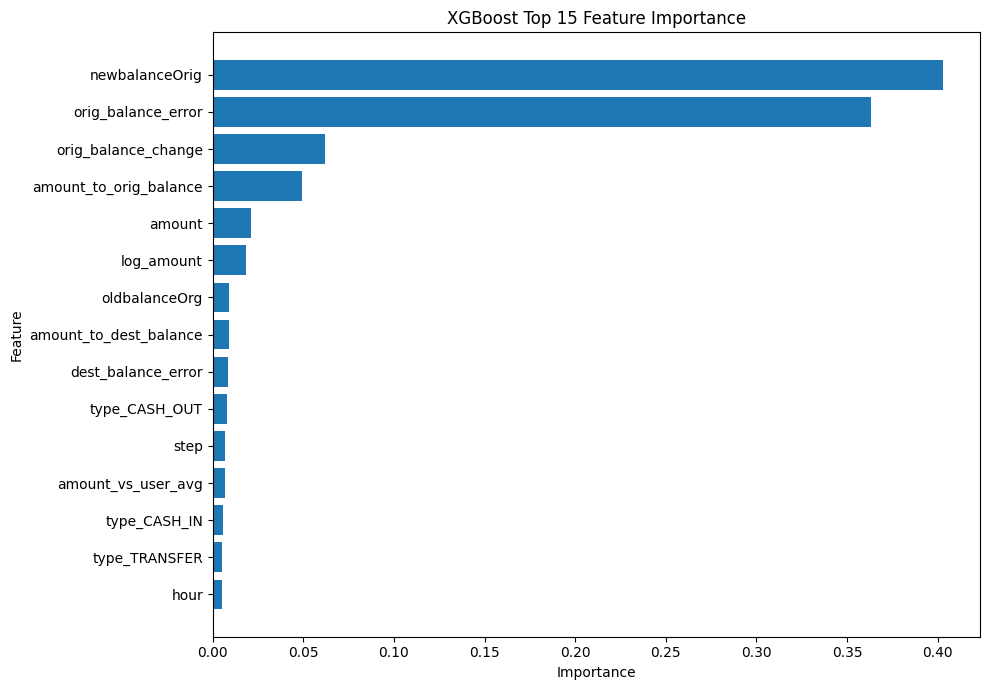

In [22]:
# ============================================
# PART 11: FEATURE IMPORTANCE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------------------
# 1. Get feature importance
# --------------------------------------------

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})


# --------------------------------------------
# 2. Sort by importance
# --------------------------------------------

importance = importance.sort_values(
    by='importance',
    ascending=False
).reset_index(drop=True)


# --------------------------------------------
# 3. Print top features
# --------------------------------------------

print("\n========================================")
print("TOP 20 FEATURE IMPORTANCE")
print("========================================")

print(
    importance.head(20).to_string(index=False)
)


# --------------------------------------------
# 4. Plot top 15
# --------------------------------------------

top_features = importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Top 15 Feature Importance")

plt.tight_layout()
plt.show()

In [23]:
!pip install shap -q

Creating SHAP explainer...
SHAP explainer created!

SELECTED TRANSACTION
                             5413424
step                    3.780000e+02
amount                  1.877618e+05
oldbalanceOrg           1.877618e+05
newbalanceOrig          0.000000e+00
oldbalanceDest          0.000000e+00
newbalanceDest          0.000000e+00
orig_balance_change     1.877618e+05
dest_balance_change     0.000000e+00
amount_to_orig_balance  9.999947e-01
amount_to_dest_balance  1.877618e+05
orig_balance_error      0.000000e+00
dest_balance_error      1.877618e+05
log_amount              1.214293e+01
hour                    1.800000e+01
day                     1.500000e+01
is_night                0.000000e+00
hour_sin               -1.000000e+00
hour_cos               -1.836970e-16
user_tx_count_before    0.000000e+00
user_amount_sum_before  0.000000e+00
user_avg_amount_before  0.000000e+00
amount_vs_user_avg      1.877618e+05
user_max_amount_before  0.000000e+00
type_CASH_IN            0.000000e+00
ty

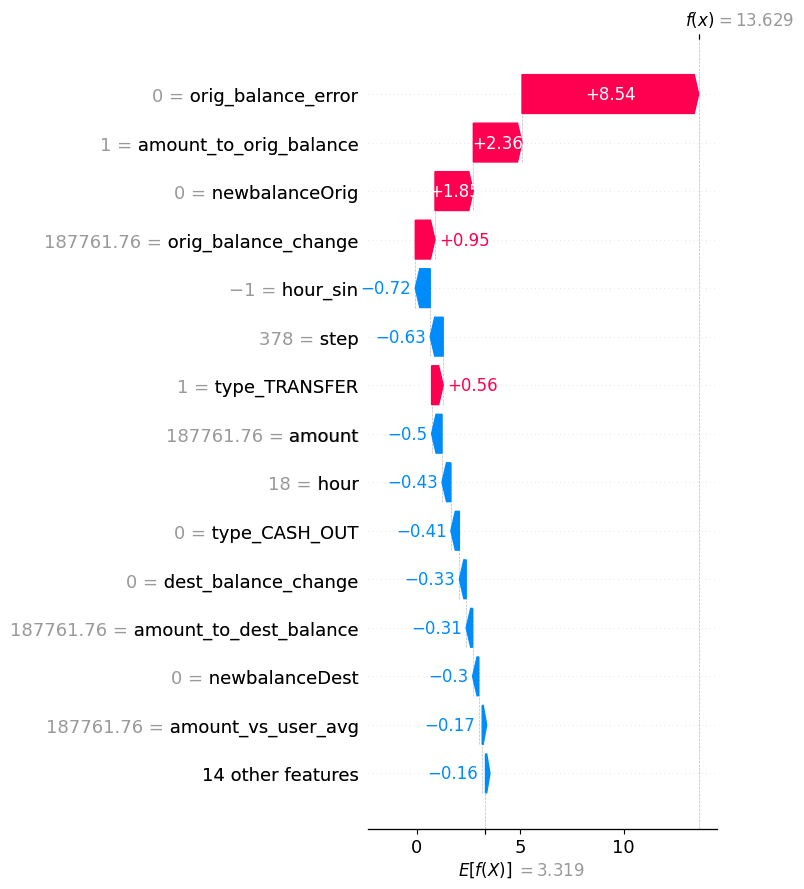

In [24]:
# ============================================
# PART 12: SHAP EXPLAINABILITY
# ============================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Creating SHAP explainer...")

# --------------------------------------------
# 1. Create SHAP Explainer
# --------------------------------------------

explainer = shap.TreeExplainer(xgb_model)

print("SHAP explainer created!")


# --------------------------------------------
# 2. Select a sample from test data
# --------------------------------------------

# Fraud transaction থেকে sample নেওয়া
fraud_indices = np.where(y_test.values == 1)[0]

sample_index = fraud_indices[0]

X_sample = X_test.iloc[[sample_index]]

print("\n========================================")
print("SELECTED TRANSACTION")
print("========================================")

print(X_sample.T)


# --------------------------------------------
# 3. Calculate SHAP values
# --------------------------------------------

shap_values = explainer.shap_values(X_sample)

print("\nSHAP values calculated!")


# --------------------------------------------
# 4. Model prediction
# --------------------------------------------

prediction_probability = xgb_model.predict_proba(
    X_sample
)[0, 1]

print("\n========================================")
print("PREDICTION")
print("========================================")

print(
    f"Fraud Probability: {prediction_probability:.6f}"
)


# --------------------------------------------
# 5. SHAP Waterfall Plot
# --------------------------------------------

shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_sample.iloc[0].values,
    feature_names=X_sample.columns
)

plt.figure(figsize=(10, 8))

shap.plots.waterfall(
    shap_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()


Calculating SHAP values for validation sample...
SHAP calculation completed!


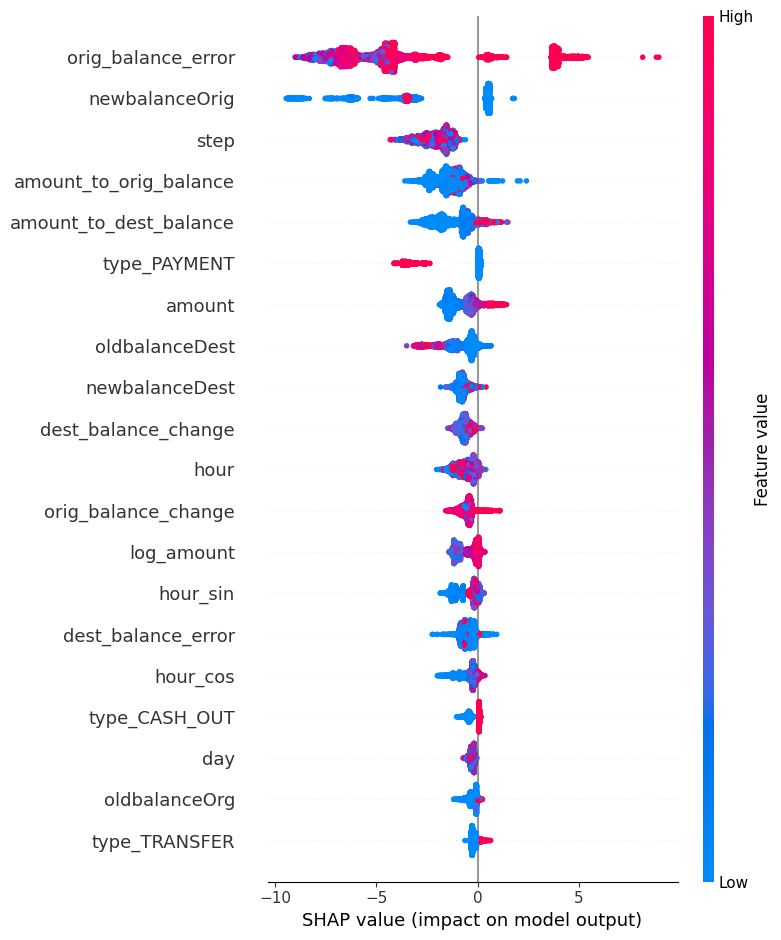

In [25]:
# ============================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================

print("\nCalculating SHAP values for validation sample...")

# পুরো 954k validation data না নিয়ে sample নিচ্ছি
sample_size = 5000

X_shap = X_val.sample(
    n=min(sample_size, len(X_val)),
    random_state=42
)

shap_values_global = explainer.shap_values(X_shap)

print("SHAP calculation completed!")


# --------------------------------------------
# Global Feature Importance
# --------------------------------------------

shap.summary_plot(
    shap_values_global,
    X_shap,
    max_display=20
)

In [26]:
# ============================================
# PART 13: ISOLATION FOREST
# BEHAVIORAL ANOMALY DETECTION
# ============================================

from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd
import time


# --------------------------------------------
# 1. Select normal transactions from training
# --------------------------------------------

normal_indices = y_train[y_train == 0].index

print("Total normal training transactions:",
      len(normal_indices))


# Use a manageable sample
ANOMALY_SAMPLE_SIZE = 200000

sample_indices = np.random.RandomState(42).choice(
    normal_indices,
    size=min(ANOMALY_SAMPLE_SIZE, len(normal_indices)),
    replace=False
)

X_anomaly_train = X_train.loc[sample_indices].copy()

print("\nAnomaly training data shape:")
print(X_anomaly_train.shape)


# --------------------------------------------
# 2. Train Isolation Forest
# --------------------------------------------

print("\n========================================")
print("TRAINING ISOLATION FOREST")
print("========================================")

start_time = time.time()

iso_model = IsolationForest(
    n_estimators=150,
    max_samples=10000,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_anomaly_train)

training_time = time.time() - start_time

print("\nIsolation Forest training completed!")

print(
    f"Training time: {training_time / 60:.2f} minutes"
)


# --------------------------------------------
# 3. Generate anomaly predictions
# --------------------------------------------

print("\nGenerating anomaly predictions...")

X_test_anomaly = X_test.copy()

anomaly_prediction = iso_model.predict(
    X_test_anomaly
)

anomaly_score = iso_model.decision_function(
    X_test_anomaly
)


# --------------------------------------------
# 4. Convert prediction
# --------------------------------------------

# Isolation Forest:
#  1  = Normal
# -1  = Anomaly

X_test_anomaly['anomaly_prediction'] = (
    anomaly_prediction
)

X_test_anomaly['anomaly_score'] = (
    anomaly_score
)


# --------------------------------------------
# 5. Display results
# --------------------------------------------

print("\n========================================")
print("ANOMALY DETECTION RESULTS")
print("========================================")

print(
    X_test_anomaly['anomaly_prediction']
    .value_counts()
)


print("\nAnomaly percentage:")

anomaly_percentage = (
    (anomaly_prediction == -1).sum()
    / len(anomaly_prediction)
) * 100

print(
    f"{anomaly_percentage:.4f}%"
)


# --------------------------------------------
# 6. Score statistics
# --------------------------------------------

print("\n========================================")
print("ANOMALY SCORE STATISTICS")
print("========================================")

print(
    pd.Series(anomaly_score).describe()
)

Total normal training transactions: 4450191

Anomaly training data shape:
(200000, 28)

TRAINING ISOLATION FOREST

Isolation Forest training completed!
Training time: 0.25 minutes

Generating anomaly predictions...

ANOMALY DETECTION RESULTS
anomaly_prediction
 1    933399
-1     20994
Name: count, dtype: int64

Anomaly percentage:
2.1997%

ANOMALY SCORE STATISTICS
count    954393.000000
mean          0.111749
std           0.035617
min          -0.251936
25%           0.104966
50%           0.121879
75%           0.131989
max           0.152571
dtype: float64


In [27]:
# ============================================
# PART 14: ANOMALY SCORE EVALUATION
# ============================================

import pandas as pd
import numpy as np


# --------------------------------------------
# 1. Create evaluation dataframe
# --------------------------------------------

anomaly_results = pd.DataFrame({
    'isFraud': y_test.values,
    'anomaly_prediction': anomaly_prediction,
    'anomaly_score': anomaly_score
})


# --------------------------------------------
# 2. Separate fraud and normal
# --------------------------------------------

normal_scores = anomaly_results[
    anomaly_results['isFraud'] == 0
]['anomaly_score']

fraud_scores = anomaly_results[
    anomaly_results['isFraud'] == 1
]['anomaly_score']


# --------------------------------------------
# 3. Score statistics
# --------------------------------------------

print("\n========================================")
print("NORMAL VS FRAUD ANOMALY SCORE")
print("========================================")

print("\nNormal transactions:")
print(normal_scores.describe())

print("\nFraud transactions:")
print(fraud_scores.describe())


# --------------------------------------------
# 4. Mean and median comparison
# --------------------------------------------

print("\n========================================")
print("MEAN / MEDIAN COMPARISON")
print("========================================")

print(
    f"Normal Mean   : {normal_scores.mean():.6f}"
)

print(
    f"Fraud Mean    : {fraud_scores.mean():.6f}"
)

print(
    f"Normal Median : {normal_scores.median():.6f}"
)

print(
    f"Fraud Median  : {fraud_scores.median():.6f}"
)


# --------------------------------------------
# 5. Anomaly detection performance
# --------------------------------------------

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Isolation Forest:
# -1 = anomaly
#  1 = normal

anomaly_pred_binary = (
    anomaly_prediction == -1
).astype(int)


precision = precision_score(
    y_test,
    anomaly_pred_binary,
    zero_division=0
)

recall = recall_score(
    y_test,
    anomaly_pred_binary,
    zero_division=0
)

f1 = f1_score(
    y_test,
    anomaly_pred_binary,
    zero_division=0
)


print("\n========================================")
print("ISOLATION FOREST FRAUD DETECTION")
print("========================================")

print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1 Score  : {f1:.6f}")


# --------------------------------------------
# 6. Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(
    y_test,
    anomaly_pred_binary
)

print("\nConfusion Matrix:")
print(cm)


NORMAL VS FRAUD ANOMALY SCORE

Normal transactions:
count    950385.000000
mean          0.112290
std           0.034082
min          -0.229547
25%           0.105251
50%           0.121961
75%           0.132013
max           0.152571
Name: anomaly_score, dtype: float64

Fraud transactions:
count    4008.000000
mean       -0.016603
std         0.100479
min        -0.251936
25%        -0.094289
50%        -0.018929
75%         0.077531
max         0.146846
Name: anomaly_score, dtype: float64

MEAN / MEDIAN COMPARISON
Normal Mean   : 0.112290
Fraud Mean    : -0.016603
Normal Median : 0.121961
Fraud Median  : -0.018929

ISOLATION FOREST FRAUD DETECTION
Precision : 0.104887
Recall    : 0.549401
F1 Score  : 0.176146

Confusion Matrix:
[[931593  18792]
 [  1806   2202]]


In [28]:
# ============================================
# PART 15: ADAPTIVE RISK SCORE
# ============================================

import numpy as np
import pandas as pd


# --------------------------------------------
# 1. XGBoost fraud probability
# --------------------------------------------

xgb_probability = xgb_model.predict_proba(
    X_test
)[:, 1]


# --------------------------------------------
# 2. Convert Isolation Forest score
# --------------------------------------------

# Lower decision_function score
# = more anomalous

anomaly_risk = 1 - (
    (anomaly_score - anomaly_score.min())
    /
    (anomaly_score.max() - anomaly_score.min())
)


# --------------------------------------------
# 3. Combine both signals
# --------------------------------------------

X_test_risk = X_test.copy()

X_test_risk['xgb_fraud_probability'] = (
    xgb_probability
)

X_test_risk['anomaly_risk'] = (
    anomaly_risk
)


# Initial weighting
X_test_risk['adaptive_risk_score'] = (
    0.70 * xgb_probability
    +
    0.30 * anomaly_risk
)


# --------------------------------------------
# 4. Convert to 0-100
# --------------------------------------------

X_test_risk['risk_score_100'] = (
    X_test_risk['adaptive_risk_score'] * 100
)


# --------------------------------------------
# 5. Risk level
# --------------------------------------------

X_test_risk['risk_level'] = pd.cut(
    X_test_risk['risk_score_100'],
    bins=[-1, 30, 70, 100],
    labels=[
        'LOW',
        'MEDIUM',
        'HIGH'
    ]
)


# --------------------------------------------
# 6. Show results
# --------------------------------------------

print("\n========================================")
print("ADAPTIVE RISK SCORE")
print("========================================")

print(
    X_test_risk[
        [
            'xgb_fraud_probability',
            'anomaly_risk',
            'risk_score_100',
            'risk_level'
        ]
    ].head(20)
)


# --------------------------------------------
# 7. Risk distribution
# --------------------------------------------

print("\n========================================")
print("RISK LEVEL DISTRIBUTION")
print("========================================")

print(
    X_test_risk['risk_level']
    .value_counts()
)


# --------------------------------------------
# 8. Fraud vs normal risk score
# --------------------------------------------

risk_comparison = pd.DataFrame({
    'isFraud': y_test.values,
    'risk_score': X_test_risk[
        'risk_score_100'
    ].values
})


print("\n========================================")
print("NORMAL VS FRAUD RISK SCORE")
print("========================================")

print(
    risk_comparison
    .groupby('isFraud')['risk_score']
    .agg([
        'count',
        'mean',
        'median',
        'min',
        'max'
    ])
)


ADAPTIVE RISK SCORE
         xgb_fraud_probability  anomaly_risk  risk_score_100 risk_level
5408227           4.548723e-07      0.094129        2.823890        LOW
5408228           3.086877e-07      0.060860        1.825829        LOW
5408229           5.048652e-07      0.084131        2.523962        LOW
5408230           4.316830e-07      0.189066        5.672016        LOW
5408231           2.284074e-06      0.281721        8.451786        LOW
5408232           3.013947e-07      0.044828        1.344873        LOW
5408233           2.418913e-06      0.031112        0.933524        LOW
5408234           5.134854e-06      0.063466        1.904332        LOW
5408235           4.316830e-07      0.169460        5.083828        LOW
5408236           2.757062e-08      0.061989        1.859685        LOW
5408237           2.824771e-06      0.068446        2.053576        LOW
5408238           9.038109e-08      0.052192        1.565764        LOW
5408239           9.789671e-08      0.14379

In [29]:
# ============================================
# PART 16: RISK THRESHOLD OPTIMIZATION
# ============================================

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------
# 1. XGBoost probability on validation
# --------------------------------------------

xgb_val_probability = xgb_model.predict_proba(
    X_val
)[:, 1]


# --------------------------------------------
# 2. Isolation Forest score on validation
# --------------------------------------------

val_anomaly_score = iso_model.decision_function(
    X_val
)


# --------------------------------------------
# 3. Convert anomaly score to anomaly risk
# --------------------------------------------

val_anomaly_risk = 1 - (
    (val_anomaly_score - anomaly_score.min())
    /
    (anomaly_score.max() - anomaly_score.min())
)


# --------------------------------------------
# 4. Adaptive validation risk score
# --------------------------------------------

val_risk_score = (
    0.70 * xgb_val_probability
    +
    0.30 * val_anomaly_risk
)

val_risk_score_100 = val_risk_score * 100


# --------------------------------------------
# 5. Test different thresholds
# --------------------------------------------

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

threshold_results = []


for threshold in thresholds:

    predictions = (
        val_risk_score >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })


# --------------------------------------------
# 6. Create result dataframe
# --------------------------------------------

threshold_df = pd.DataFrame(
    threshold_results
)


# --------------------------------------------
# 7. Find best F1 threshold
# --------------------------------------------

best_row = threshold_df.loc[
    threshold_df['f1'].idxmax()
]


print("\n========================================")
print("BEST RISK THRESHOLD")
print("========================================")

print(
    f"Threshold : {best_row['threshold']:.2f}"
)

print(
    f"Precision : {best_row['precision']:.6f}"
)

print(
    f"Recall    : {best_row['recall']:.6f}"
)

print(
    f"F1 Score  : {best_row['f1']:.6f}"
)


# --------------------------------------------
# 8. Show top thresholds
# --------------------------------------------

print("\n========================================")
print("TOP THRESHOLDS")
print("========================================")

print(
    threshold_df
    .sort_values(
        'f1',
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)


BEST RISK THRESHOLD
Threshold : 0.32
Precision : 1.000000
Recall    : 1.000000
F1 Score  : 1.000000

TOP THRESHOLDS
 threshold  precision  recall  f1
      0.51        1.0     1.0 1.0
      0.43        1.0     1.0 1.0
      0.44        1.0     1.0 1.0
      0.45        1.0     1.0 1.0
      0.46        1.0     1.0 1.0
      0.47        1.0     1.0 1.0
      0.42        1.0     1.0 1.0
      0.40        1.0     1.0 1.0
      0.41        1.0     1.0 1.0
      0.35        1.0     1.0 1.0


In [30]:
# ============================================
# PART 17: FINAL ADAPTIVE RISK EVALUATION
# ============================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# --------------------------------------------
# 1. Apply validation-selected threshold
# --------------------------------------------

best_threshold = best_row['threshold']

adaptive_test_prediction = (
    X_test_risk['adaptive_risk_score']
    >= best_threshold
).astype(int)


# --------------------------------------------
# 2. Calculate metrics
# --------------------------------------------

adaptive_precision = precision_score(
    y_test,
    adaptive_test_prediction,
    zero_division=0
)

adaptive_recall = recall_score(
    y_test,
    adaptive_test_prediction,
    zero_division=0
)

adaptive_f1 = f1_score(
    y_test,
    adaptive_test_prediction,
    zero_division=0
)

adaptive_roc_auc = roc_auc_score(
    y_test,
    X_test_risk['adaptive_risk_score']
)

adaptive_pr_auc = average_precision_score(
    y_test,
    X_test_risk['adaptive_risk_score']
)


# --------------------------------------------
# 3. Print results
# --------------------------------------------

print("\n========================================")
print("FINAL ADAPTIVE RISK RESULTS")
print("========================================")

print(
    f"Threshold : {best_threshold:.2f}"
)

print(
    f"Precision : {adaptive_precision:.6f}"
)

print(
    f"Recall    : {adaptive_recall:.6f}"
)

print(
    f"F1 Score  : {adaptive_f1:.6f}"
)

print(
    f"ROC-AUC   : {adaptive_roc_auc:.6f}"
)

print(
    f"PR-AUC    : {adaptive_pr_auc:.6f}"
)


# --------------------------------------------
# 4. Classification report
# --------------------------------------------

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================")

print(
    classification_report(
        y_test,
        adaptive_test_prediction,
        digits=6,
        zero_division=0
    )
)


# --------------------------------------------
# 5. Confusion Matrix
# --------------------------------------------

print("\n========================================")
print("CONFUSION MATRIX")
print("========================================")

adaptive_cm = confusion_matrix(
    y_test,
    adaptive_test_prediction
)

print(adaptive_cm)


FINAL ADAPTIVE RISK RESULTS
Threshold : 0.32
Precision : 1.000000
Recall    : 0.999501
F1 Score  : 0.999750
ROC-AUC   : 0.999984
PR-AUC    : 0.999597

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0   0.999998  1.000000  0.999999    950385
           1   1.000000  0.999501  0.999750      4008

    accuracy                       0.999998    954393
   macro avg   0.999999  0.999750  0.999875    954393
weighted avg   0.999998  0.999998  0.999998    954393


CONFUSION MATRIX
[[950385      0]
 [     2   4006]]


In [31]:
# ============================================
# PART 18: MODEL COMPARISON
# ============================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# ============================================
# 1. XGBoost Results
# ============================================

xgb_pred = (
    y_test_proba >= 0.5
).astype(int)

xgb_precision = precision_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred,
    zero_division=0
)

xgb_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

xgb_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)


# ============================================
# 2. Isolation Forest Results
# ============================================

iso_pred = (
    anomaly_prediction == -1
).astype(int)

iso_precision = precision_score(
    y_test,
    iso_pred,
    zero_division=0
)

iso_recall = recall_score(
    y_test,
    iso_pred,
    zero_division=0
)

iso_f1 = f1_score(
    y_test,
    iso_pred,
    zero_division=0
)

iso_roc_auc = roc_auc_score(
    y_test,
    -anomaly_score
)

iso_pr_auc = average_precision_score(
    y_test,
    -anomaly_score
)


# ============================================
# 3. Adaptive Risk Results
# ============================================

adaptive_pred = (
    X_test_risk['adaptive_risk_score']
    >= best_threshold
).astype(int)

adaptive_precision = precision_score(
    y_test,
    adaptive_pred,
    zero_division=0
)

adaptive_recall = recall_score(
    y_test,
    adaptive_pred,
    zero_division=0
)

adaptive_f1 = f1_score(
    y_test,
    adaptive_pred,
    zero_division=0
)

adaptive_roc_auc = roc_auc_score(
    y_test,
    X_test_risk['adaptive_risk_score']
)

adaptive_pr_auc = average_precision_score(
    y_test,
    X_test_risk['adaptive_risk_score']
)


# ============================================
# 4. Create Comparison Table
# ============================================

comparison = pd.DataFrame({

    'Model': [
        'XGBoost',
        'Isolation Forest',
        'Adaptive Risk Engine'
    ],

    'Precision': [
        xgb_precision,
        iso_precision,
        adaptive_precision
    ],

    'Recall': [
        xgb_recall,
        iso_recall,
        adaptive_recall
    ],

    'F1 Score': [
        xgb_f1,
        iso_f1,
        adaptive_f1
    ],

    'ROC-AUC': [
        xgb_roc_auc,
        iso_roc_auc,
        adaptive_roc_auc
    ],

    'PR-AUC': [
        xgb_pr_auc,
        iso_pr_auc,
        adaptive_pr_auc
    ]
})


# ============================================
# 5. Display Results
# ============================================

print("\n========================================")
print("MODEL COMPARISON")
print("========================================")

print(
    comparison.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)



MODEL COMPARISON
               Model  Precision   Recall  F1 Score  ROC-AUC   PR-AUC
             XGBoost   1.000000 0.999501  0.999750 1.000000 0.999995
    Isolation Forest   0.104887 0.549401  0.176146 0.891150 0.239855
Adaptive Risk Engine   1.000000 0.999501  0.999750 0.999984 0.999597


In [32]:
# ============================================
# PART 19: FEATURE LEAKAGE / SHORTCUT ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import time

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)


# ============================================
# 1. Define Feature Groups
# ============================================

balance_derived_features = [
    'orig_balance_change',
    'dest_balance_change',
    'amount_to_orig_balance',
    'amount_to_dest_balance',
    'orig_balance_error',
    'dest_balance_error'
]

time_features = [
    'step',
    'hour',
    'day',
    'is_night',
    'hour_sin',
    'hour_cos'
]

behavioral_features = [
    'user_tx_count_before',
    'user_amount_sum_before',
    'user_avg_amount_before',
    'amount_vs_user_avg',
    'user_max_amount_before'
]


# ============================================
# 2. Function to Train + Evaluate
# ============================================

def run_ablation_experiment(
    experiment_name,
    features_to_remove
):

    print("\n" + "=" * 60)
    print(experiment_name)
    print("=" * 60)

    selected_features = [
        col for col in X_train.columns
        if col not in features_to_remove
    ]

    print("Features removed:", len(features_to_remove))
    print("Features remaining:", len(selected_features))

    Xtr = X_train[selected_features]
    Xv = X_val[selected_features]
    Xt = X_test[selected_features]

    model = XGBClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.15,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective='binary:logistic',
        eval_metric='aucpr',
        tree_method='hist',
        device='cuda',
        n_jobs=-1,
        random_state=42
    )

    start_time = time.time()

    model.fit(
        Xtr,
        y_train,
        eval_set=[(Xv, y_val)],
        verbose=False
    )

    training_time = time.time() - start_time

    # Test probability
    test_proba = model.predict_proba(Xt)[:, 1]

    # Default threshold
    test_pred = (
        test_proba >= 0.5
    ).astype(int)

    # Metrics
    precision = precision_score(
        y_test,
        test_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        test_proba
    )

    pr_auc = average_precision_score(
        y_test,
        test_proba
    )

    print(f"Training time : {training_time:.2f} sec")
    print(f"Precision     : {precision:.6f}")
    print(f"Recall        : {recall:.6f}")
    print(f"F1 Score      : {f1:.6f}")
    print(f"ROC-AUC       : {roc_auc:.6f}")
    print(f"PR-AUC        : {pr_auc:.6f}")

    return {
        'Experiment': experiment_name,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Training Time (sec)': training_time,
        'Features Used': len(selected_features)
    }


# ============================================
# 3. Run Experiments
# ============================================

results = []


# --------------------------------------------
# Experiment 1: All Features
# --------------------------------------------

results.append(
    run_ablation_experiment(
        "All Features",
        []
    )
)


# --------------------------------------------
# Experiment 2: Remove orig_balance_error
# --------------------------------------------

results.append(
    run_ablation_experiment(
        "Remove orig_balance_error",
        ['orig_balance_error']
    )
)


# --------------------------------------------
# Experiment 3: Remove All Balance-Derived
# --------------------------------------------

results.append(
    run_ablation_experiment(
        "Remove All Balance-Derived Features",
        balance_derived_features
    )
)


# --------------------------------------------
# Experiment 4: Remove Time Features
# --------------------------------------------

results.append(
    run_ablation_experiment(
        "Remove Time Features",
        time_features
    )
)


# --------------------------------------------
# Experiment 5: Remove Behavioral Features
# --------------------------------------------

results.append(
    run_ablation_experiment(
        "Remove Behavioral Features",
        behavioral_features
    )
)


# ============================================
# 4. Final Comparison Table
# ============================================

ablation_results = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("ABLATION STUDY RESULTS")
print("=" * 80)

print(
    ablation_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


All Features
Features removed: 0
Features remaining: 28
Training time : 22.53 sec
Precision     : 1.000000
Recall        : 0.999501
F1 Score      : 0.999750
ROC-AUC       : 1.000000
PR-AUC        : 0.999995

Remove orig_balance_error
Features removed: 1
Features remaining: 27
Training time : 19.76 sec
Precision     : 0.852196
Recall        : 0.982535
F1 Score      : 0.912736
ROC-AUC       : 0.999944
PR-AUC        : 0.987524

Remove All Balance-Derived Features
Features removed: 6
Features remaining: 22
Training time : 17.24 sec
Precision     : 0.656078
Recall        : 0.979042
F1 Score      : 0.785664
ROC-AUC       : 0.999824
PR-AUC        : 0.972450

Remove Time Features
Features removed: 6
Features remaining: 22
Training time : 18.51 sec
Precision     : 0.997510
Recall        : 0.999501
F1 Score      : 0.998504
ROC-AUC       : 1.000000
PR-AUC        : 0.999989

Remove Behavioral Features
Features removed: 5
Features remaining: 23
Training time : 20.17 sec
Precision     : 1.000000
Re

In [33]:
import gc
gc.collect()

13217

In [34]:
data.sort_values('step', inplace=True)
data.reset_index(drop=True, inplace=True)

data['sender_tx_count'] = (
    data.groupby('nameOrig', sort=False)
    .cumcount()
    .astype('int32')
)

data['sender_prev_amount'] = (
    data.groupby('nameOrig', sort=False)['amount']
    .shift(1)
    .fillna(0)
    .astype('float32')
)

data['recipient_tx_count'] = (
    data.groupby('nameDest', sort=False)
    .cumcount()
    .astype('int32')
)

print("Behavioral features created!")

print(
    data[
        [
            'sender_tx_count',
            'sender_prev_amount',
            'recipient_tx_count'
        ]
    ].describe()
)

Behavioral features created!
       sender_tx_count  sender_prev_amount  recipient_tx_count
count     6.362620e+06        6.362620e+06        6.362620e+06
mean      1.466063e-03        2.603940e+02        5.096119e+00
std       3.832269e-02        2.979290e+04        7.846729e+00
min       0.000000e+00        0.000000e+00        0.000000e+00
25%       0.000000e+00        0.000000e+00        0.000000e+00
50%       0.000000e+00        0.000000e+00        1.000000e+00
75%       0.000000e+00        0.000000e+00        7.000000e+00
max       2.000000e+00        4.621192e+07        1.120000e+02


In [35]:
# ============================================
# PART 21: COUNTERFACTUAL RISK ANALYSIS
# RAM OPTIMIZED
# ============================================

# Find only one fraud transaction
fraud_index = y_test[y_test == 1].index[0]

print("Selected transaction index:", fraud_index)

Selected transaction index: 5413424


In [36]:
original = X_test.loc[fraud_index].copy()

print("\nOriginal transaction:")
print(original)


Original transaction:
step                      3.780000e+02
amount                    1.877618e+05
oldbalanceOrg             1.877618e+05
newbalanceOrig            0.000000e+00
oldbalanceDest            0.000000e+00
newbalanceDest            0.000000e+00
orig_balance_change       1.877618e+05
dest_balance_change       0.000000e+00
amount_to_orig_balance    9.999947e-01
amount_to_dest_balance    1.877618e+05
orig_balance_error        0.000000e+00
dest_balance_error        1.877618e+05
log_amount                1.214293e+01
hour                      1.800000e+01
day                       1.500000e+01
is_night                  0.000000e+00
hour_sin                 -1.000000e+00
hour_cos                 -1.836970e-16
user_tx_count_before      0.000000e+00
user_amount_sum_before    0.000000e+00
user_avg_amount_before    0.000000e+00
amount_vs_user_avg        1.877618e+05
user_max_amount_before    0.000000e+00
type_CASH_IN              0.000000e+00
type_CASH_OUT             0.000000e+00
ty

In [37]:
original_probability = xgb_model.predict_proba(
    original.to_frame().T
)[:, 1][0]

print(
    f"\nOriginal fraud probability: "
    f"{original_probability:.6f}"
)

print(
    f"Original risk score: "
    f"{original_probability * 100:.2f}/100"
)


Original fraud probability: 0.999999
Original risk score: 100.00/100


In [38]:
counterfactual_amounts = [
    original['amount'] * 0.25,
    original['amount'] * 0.50,
    original['amount'],
    original['amount'] * 1.50,
    original['amount'] * 2.00
]

results = []

for amount in counterfactual_amounts:

    cf = original.copy()

    # Change amount
    cf['amount'] = amount

    # Update log amount
    cf['log_amount'] = np.log1p(amount)

    # Update amount-related ratios
    cf['amount_to_orig_balance'] = (
        amount /
        (cf['oldbalanceOrg'] + 1)
    )

    cf['amount_to_dest_balance'] = (
        amount /
        (cf['oldbalanceDest'] + 1)
    )

    # Update balance-change features
    cf['orig_balance_change'] = (
        cf['oldbalanceOrg']
        - cf['newbalanceOrig']
    )

    cf['dest_balance_change'] = (
        cf['newbalanceDest']
        - cf['oldbalanceDest']
    )

    # Update balance-error features
    cf['orig_balance_error'] = (
        cf['oldbalanceOrg']
        - amount
        - cf['newbalanceOrig']
    )

    cf['dest_balance_error'] = (
        cf['oldbalanceDest']
        + amount
        - cf['newbalanceDest']
    )

    # Update amount vs user average
    cf['amount_vs_user_avg'] = (
        amount /
        (cf['user_avg_amount_before'] + 1)
    )

    # Predict
    probability = xgb_model.predict_proba(
        cf.to_frame().T
    )[:, 1][0]

    results.append([
        amount,
        probability,
        probability * 100
    ])


counterfactual_results = pd.DataFrame(
    results,
    columns=[
        'Amount',
        'Fraud Probability',
        'Risk Score'
    ]
)

print("\n========================================")
print("COUNTERFACTUAL ANALYSIS")
print("========================================")

print(
    counterfactual_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


COUNTERFACTUAL ANALYSIS
       Amount  Fraud Probability  Risk Score
 46940.440000           0.323337   32.333664
 93880.880000           0.464783   46.478340
187761.760000           0.999999   99.999878
281642.640000           0.000045    0.004535
375523.520000           0.000030    0.002952


In [39]:
# ============================================
# PART 22: STRICT TEMPORAL SPLIT
# RAM OPTIMIZED
# ============================================

# Unique step values
unique_steps = np.sort(
    data['step'].unique()
)

print("Total unique steps:", len(unique_steps))

# 70% / 15% / 15% step boundaries
train_step_end = int(len(unique_steps) * 0.70)
val_step_end = int(len(unique_steps) * 0.85)

train_last_step = unique_steps[train_step_end - 1]
val_last_step = unique_steps[val_step_end - 1]

print("Train last step:", train_last_step)
print("Validation last step:", val_last_step)
print("Test starts after step:", val_last_step)

Total unique steps: 743
Train last step: 520
Validation last step: 631
Test starts after step: 631


In [40]:
# ============================================
# Create row indices
# ============================================

train_idx = data.index[
    data['step'] <= train_last_step
]

val_idx = data.index[
    (data['step'] > train_last_step) &
    (data['step'] <= val_last_step)
]

test_idx = data.index[
    data['step'] > val_last_step
]

print("\nStrict temporal split:")

print("Train rows:", len(train_idx))
print("Validation rows:", len(val_idx))
print("Test rows:", len(test_idx))


Strict temporal split:
Train rows: 6082007
Validation rows: 191147
Test rows: 89466


In [41]:
# ============================================
# Create strict temporal datasets
# ============================================

X_strict_train = X.loc[train_idx]
y_strict_train = y.loc[train_idx]

X_strict_val = X.loc[val_idx]
y_strict_val = y.loc[val_idx]

X_strict_test = X.loc[test_idx]
y_strict_test = y.loc[test_idx]

print("\nShapes:")

print("Train:", X_strict_train.shape)
print("Validation:", X_strict_val.shape)
print("Test:", X_strict_test.shape)


Shapes:
Train: (6082007, 28)
Validation: (191147, 28)
Test: (89466, 28)


In [42]:
# ============================================
# Fraud distribution
# ============================================

print("\n========================================")
print("FRAUD DISTRIBUTION")
print("========================================")

for name, target in [
    ("Train", y_strict_train),
    ("Validation", y_strict_val),
    ("Test", y_strict_test)
]:

    fraud = int((target == 1).sum())
    normal = int((target == 0).sum())
    total = len(target)

    print(f"\n{name}")
    print("Total :", total)
    print("Normal:", normal)
    print("Fraud :", fraud)
    print(
        "Fraud %:",
        round((fraud / total) * 100, 6)
    )


FRAUD DISTRIBUTION

Train
Total : 6082007
Normal: 6076226
Fraud : 5781
Fraud %: 0.095051

Validation
Total : 191147
Normal: 189967
Fraud : 1180
Fraud %: 0.617326

Test
Total : 89466
Normal: 88214
Fraud : 1252
Fraud %: 1.399414


In [43]:
# ============================================
# Strict Temporal XGBoost
# ============================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

strict_negative = (
    y_strict_train == 0
).sum()

strict_positive = (
    y_strict_train == 1
).sum()

strict_scale_pos_weight = (
    strict_negative / strict_positive
)

print(
    "\nScale pos weight:",
    strict_scale_pos_weight
)


strict_xgb = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.15,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=strict_scale_pos_weight,
    objective='binary:logistic',
    eval_metric='aucpr',
    tree_method='hist',
    device='cuda',
    n_jobs=-1,
    random_state=42
)


strict_xgb.fit(
    X_strict_train,
    y_strict_train,
    eval_set=[
        (X_strict_val, y_strict_val)
    ],
    verbose=20
)


Scale pos weight: 1051.0683272790175
[0]	validation_0-aucpr:0.99939
[20]	validation_0-aucpr:0.99990
[40]	validation_0-aucpr:0.99986
[60]	validation_0-aucpr:0.99984
[80]	validation_0-aucpr:0.99998
[100]	validation_0-aucpr:0.99999
[120]	validation_0-aucpr:1.00000
[140]	validation_0-aucpr:1.00000
[149]	validation_0-aucpr:1.00000


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=-1, num_parallel_tree=None, ...)

In [44]:
# ============================================
# Strict Temporal Test Evaluation
# ============================================

strict_test_proba = (
    strict_xgb
    .predict_proba(X_strict_test)[:, 1]
)

strict_test_pred = (
    strict_test_proba >= 0.5
).astype(int)


strict_precision = precision_score(
    y_strict_test,
    strict_test_pred,
    zero_division=0
)

strict_recall = recall_score(
    y_strict_test,
    strict_test_pred,
    zero_division=0
)

strict_f1 = f1_score(
    y_strict_test,
    strict_test_pred,
    zero_division=0
)

strict_roc_auc = roc_auc_score(
    y_strict_test,
    strict_test_proba
)

strict_pr_auc = average_precision_score(
    y_strict_test,
    strict_test_proba
)


print("\n========================================")
print("STRICT TEMPORAL TEST RESULTS")
print("========================================")

print(f"Precision : {strict_precision:.6f}")
print(f"Recall    : {strict_recall:.6f}")
print(f"F1 Score  : {strict_f1:.6f}")
print(f"ROC-AUC   : {strict_roc_auc:.6f}")
print(f"PR-AUC    : {strict_pr_auc:.6f}")


STRICT TEMPORAL TEST RESULTS
Precision : 1.000000
Recall    : 0.999201
F1 Score  : 0.999600
ROC-AUC   : 1.000000
PR-AUC    : 0.999994


In [45]:
# ============================================
# PART 23: FINAL MODEL VALIDATION
# RAM OPTIMIZED
# ============================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Final test prediction
final_proba = strict_xgb.predict_proba(
    X_strict_test
)[:, 1]

final_pred = (
    final_proba >= 0.5
).astype(int)


# Metrics
final_precision = precision_score(
    y_strict_test,
    final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_strict_test,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_strict_test,
    final_pred,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_strict_test,
    final_proba
)

final_pr_auc = average_precision_score(
    y_strict_test,
    final_proba
)


print("========================================")
print("FINAL STRICT TEMPORAL MODEL")
print("========================================")

print(f"Precision : {final_precision:.6f}")
print(f"Recall    : {final_recall:.6f}")
print(f"F1 Score  : {final_f1:.6f}")
print(f"ROC-AUC   : {final_roc_auc:.6f}")
print(f"PR-AUC    : {final_pr_auc:.6f}")


# Confusion matrix
cm = confusion_matrix(
    y_strict_test,
    final_pred
)

print("\nConfusion Matrix:")
print(cm)


print("\nClassification Report:")
print(
    classification_report(
        y_strict_test,
        final_pred,
        digits=6
    )
)

FINAL STRICT TEMPORAL MODEL
Precision : 1.000000
Recall    : 0.999201
F1 Score  : 0.999600
ROC-AUC   : 1.000000
PR-AUC    : 0.999994

Confusion Matrix:
[[88214     0]
 [    1  1251]]

Classification Report:
              precision    recall  f1-score   support

           0   0.999989  1.000000  0.999994     88214
           1   1.000000  0.999201  0.999600      1252

    accuracy                       0.999989     89466
   macro avg   0.999994  0.999601  0.999797     89466
weighted avg   0.999989  0.999989  0.999989     89466



In [46]:
# ============================================
# FINAL FEATURE IMPORTANCE
# ============================================

importance_df = pd.DataFrame({
    'Feature': X_strict_train.columns,
    'Importance': strict_xgb.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n========================================")
print("TOP 15 FEATURES")
print("========================================")

print(
    importance_df.head(15).to_string(
        index=False
    )
)


TOP 15 FEATURES
               Feature  Importance
    orig_balance_error    0.387260
        newbalanceOrig    0.366023
   orig_balance_change    0.065357
amount_to_orig_balance    0.052705
                amount    0.024212
            log_amount    0.019741
         type_CASH_OUT    0.013475
amount_to_dest_balance    0.010393
         oldbalanceOrg    0.007532
         type_TRANSFER    0.006838
    amount_vs_user_avg    0.006734
                   day    0.005567
    dest_balance_error    0.005321
                  hour    0.004498
          type_CASH_IN    0.003150


In [47]:
# ============================================
# GLOBAL SHAP
# RAM OPTIMIZED
# ============================================

import shap

# Small sample only
shap_sample_size = min(
    2000,
    len(X_strict_test)
)

shap_sample = X_strict_test.sample(
    n=shap_sample_size,
    random_state=42
)

print(
    "SHAP sample size:",
    len(shap_sample)
)


# Create SHAP explainer
explainer = shap.TreeExplainer(
    strict_xgb
)

# Calculate SHAP values
shap_values = explainer.shap_values(
    shap_sample
)

print("SHAP calculation completed.")

SHAP sample size: 2000
SHAP calculation completed.


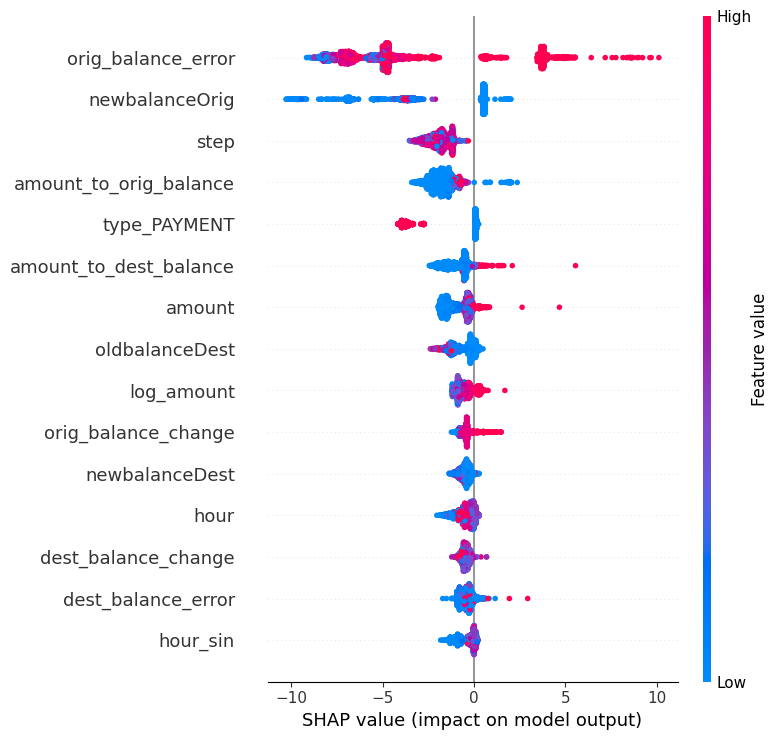

In [48]:
# ============================================
# SHAP SUMMARY PLOT
# ============================================

shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=15
)

In [49]:
# ============================================
# GLOBAL SHAP IMPORTANCE TABLE
# ============================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'Feature': shap_sample.columns,
    'Mean_Abs_SHAP': mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        'Mean_Abs_SHAP',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n========================================")
print("TOP 15 GLOBAL SHAP FEATURES")
print("========================================")

print(
    shap_importance.head(15).to_string(
        index=False
    )
)


TOP 15 GLOBAL SHAP FEATURES
               Feature  Mean_Abs_SHAP
    orig_balance_error       5.324820
        newbalanceOrig       2.750558
                  step       1.887930
amount_to_orig_balance       1.761495
          type_PAYMENT       1.361951
amount_to_dest_balance       0.937040
                amount       0.934326
        oldbalanceDest       0.656800
            log_amount       0.576672
   orig_balance_change       0.511103
        newbalanceDest       0.504996
                  hour       0.480627
   dest_balance_change       0.466045
    dest_balance_error       0.460433
              hour_sin       0.449046


In [50]:
# ============================================
# PART 24: FINAL MODEL SAVING
# ============================================

import os
import json
import joblib
import numpy as np
import pandas as pd

# --------------------------------------------
# Google Drive Model Directory
# --------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/CPC Hackathon/saved_models"

# Create model directory
os.makedirs(MODEL_DIR, exist_ok=True)

print("Model directory:", MODEL_DIR)


# --------------------------------------------
# 1. Save Final XGBoost Model
# --------------------------------------------

strict_xgb.save_model(
    os.path.join(MODEL_DIR, "final_xgb_model.json")
)

print("XGBoost model saved.")


# --------------------------------------------
# 2. Save Isolation Forest
# --------------------------------------------

joblib.dump(
    iso_model,
    os.path.join(MODEL_DIR, "isolation_forest.joblib")
)

print("Isolation Forest saved.")


# --------------------------------------------
# 3. Save Feature List
# --------------------------------------------

feature_list = list(X_strict_test.columns)

with open(
    os.path.join(MODEL_DIR, "feature_list.json"),
    "w"
) as f:
    json.dump(
        feature_list,
        f,
        indent=4
    )

print("Feature list saved.")
print("Number of features:", len(feature_list))


# --------------------------------------------
# 4. Save Model Configuration
# --------------------------------------------

model_config = {
    "model": "XGBoost",
    "task": "Binary Fraud Classification",
    "dataset": "PaySim",
    "split_strategy": "Strict Temporal Split",
    "n_features": len(feature_list),
    "n_estimators": 150,
    "max_depth": 5,
    "learning_rate": 0.15,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "random_state": 42
}

with open(
    os.path.join(MODEL_DIR, "model_config.json"),
    "w"
) as f:
    json.dump(
        model_config,
        f,
        indent=4
    )

print("Model configuration saved.")


# --------------------------------------------
# 5. Save SHAP Importance
# --------------------------------------------

shap_importance.to_csv(
    os.path.join(MODEL_DIR, "shap_feature_importance.csv"),
    index=False
)

print("SHAP importance saved.")


# ============================================
# VERIFY SAVED MODELS
# ============================================

print("\n========================================")
print("SAVED MODEL FILES")
print("========================================")

for file in os.listdir(MODEL_DIR):
    print("✓", file)

print("\n========================================")
print("SAVE LOCATION")
print("========================================")
print(MODEL_DIR)

Model directory: /content/drive/MyDrive/CPC Hackathon/saved_models
XGBoost model saved.
Isolation Forest saved.
Feature list saved.
Number of features: 28
Model configuration saved.
SHAP importance saved.

SAVED MODEL FILES
✓ final_xgb_model.json
✓ isolation_forest.joblib
✓ feature_list.json
✓ model_config.json
✓ shap_feature_importance.csv

SAVE LOCATION
/content/drive/MyDrive/CPC Hackathon/saved_models
